# Stage 8 — SciPy parametric load model

A small, interpretable load model fitted by `scipy.optimize.curve_fit`:

$$
\begin{aligned}
y_t \;=\;& \alpha
  + \beta_{\text{heat}} \cdot \text{HDD}_t
  + \beta_{\text{cool}} \cdot \text{CDD}_t \\
  & + \sum_{k=1}^{K_d}
      \big(A_k \sin(\omega_d k t) + B_k \cos(\omega_d k t)\big) \\
  & + \sum_{j=1}^{K_w}
      \big(C_j \sin(\omega_w j t) + D_j \cos(\omega_w j t)\big)
\end{aligned}
$$

with $\text{HDD}_t = \max(0, T_{\text{heat}} - T_t)$ and
$\text{CDD}_t = \max(0, T_t - T_{\text{cool}})$ at the Elexon
hinges $T_{\text{heat}}=15.5\,°\text{C}$,
$T_{\text{cool}}=22.0\,°\text{C}$ (plan D1).

The pedagogical payoff — and the reason this stage sits between the
opaque SARIMAX of Stage 7 and the registry / probabilistic work of
Stages 9 / 10 — is that every parameter carries a **physical
interpretation** and a **Gaussian confidence interval** derived from
the fitted covariance matrix.  Cell 7's "value ± 1.96 · std" table is
the punch line; Cell 12's assumptions appendix is the honesty clause.

- **Intent:** `docs/intent/08-scipy-parametric.md`.
- **Plan:** `docs/plans/completed/08-scipy-parametric.md`.
- **Previous stage:** Stage 7 SARIMAX — the flexible-but-opaque
  dynamic-harmonic-regression baseline against which this stage's
  parameter interpretability trade-off is framed.

Plan decisions applied here: D1 (piecewise-linear HDD/CDD with fixed
Elexon hinges), D2 (diurnal K=3, weekly K=2; calendar one-hots
excluded from the design matrix), D3 (`loss="linear"` default; no
robust-loss override), D4 (data-driven `p0` via `_derive_p0`), D5
(Gaussian CIs from `pcov` — assumptions explicit in Cell 12), D7
(parameter values + std errors + full covariance matrix land in
`metadata.hyperparameters`), D8 (tz-aware UTC index mandated — same
rule as SARIMAX), D9 (notebook generated from
`scripts/_build_notebook_08.py`).


In [1]:
import os
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)  # cache_dir values resolve against cwd

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

from bristol_ml import load_config  # noqa: E402
from bristol_ml.evaluation import plots  # noqa: E402
from bristol_ml.evaluation.harness import evaluate  # noqa: E402
from bristol_ml.evaluation.metrics import METRIC_REGISTRY  # noqa: E402
from bristol_ml.features import assembler  # noqa: E402
from bristol_ml.models.linear import LinearModel  # noqa: E402
from bristol_ml.models.naive import NaiveModel  # noqa: E402
from bristol_ml.models.sarimax import SarimaxModel  # noqa: E402
from bristol_ml.models.scipy_parametric import (  # noqa: E402
    ScipyParametricModel,
    _parametric_fn,
)
from conf._schemas import LinearConfig, NaiveConfig, SarimaxConfig  # noqa: E402

# Apply the Okabe-Ito palette + figsize defaults (Stage 6 D2 / D5).
plots.apply_plots_config(
    load_config(
        config_path=REPO_ROOT / "conf",
        overrides=["model=scipy_parametric"],
    ).evaluation.plots
)

# Plan D4 splitter override — fixed sliding window + weekly-ish stride,
# matching the Stage 7 notebook budget envelope (AC-3: end-to-end under
# 10 minutes).  The CLI path inherits the full-year defaults.
cfg = load_config(
    config_path=REPO_ROOT / "conf",
    overrides=[
        "model=scipy_parametric",
        "features=weather_calendar",
        "evaluation.rolling_origin.fixed_window=true",
        "evaluation.rolling_origin.min_train_periods=720",
        "evaluation.rolling_origin.step=1344",
        "evaluation.rolling_origin.test_len=168",
    ],
)
assert cfg.features.weather_calendar is not None

# Load the calendar-feature table written by `python -m
# bristol_ml.features.assembler --calendar`.
features_path = (
    cfg.features.weather_calendar.cache_dir / cfg.features.weather_calendar.cache_filename
)
df = assembler.load_calendar(features_path).set_index("timestamp_utc")
print("Feature table:", df.shape, df.index.min(), "->", df.index.max())

# Stage 8 design matrix: temperature column only (Fourier terms are
# appended inside `ScipyParametricModel.fit`; calendar one-hots are
# deliberately excluded per plan D2 clarification — the parametric
# Fourier harmonics and the calendar dummies would be collinear).
scipy_feature_cols = ("temperature_2m",)

# The Linear / SARIMAX baselines keep their Stage 5 / Stage 7 exog set —
# temperature + 44 calendar one-hots — so the cross-model comparison is
# apples-to-apples against the shipped defaults.
calendar_cols = [
    c
    for c in df.columns
    if c.startswith(("hour_of_day_", "day_of_week_", "month_", "is_"))
    and not c.endswith("_retrieved_at_utc")
]
baseline_exog_cols = ["temperature_2m", *calendar_cols]
print(
    f"Scipy-parametric feature set: {len(scipy_feature_cols)} column(s) "
    f"({scipy_feature_cols[0]!r}); Fourier cols appended at fit time."
)
print(
    f"Naive / Linear / SARIMAX baseline exog: {len(baseline_exog_cols)} columns "
    f"(temperature_2m + {len(calendar_cols)} calendar one-hots)."
)

Feature table: (70128, 55) 2018-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00
Scipy-parametric feature set: 1 column(s) ('temperature_2m'); Fourier cols appended at fit time.
Naive / Linear / SARIMAX baseline exog: 46 columns (temperature_2m + 45 calendar one-hots).


## Temperature response: heating, cooling, base load

GB electricity demand has a **U-shaped** response to outdoor
temperature.  Three physical regimes produce three parameter slopes:

1. **Heating** — below the heating balance point (around 15.5 °C,
   per Elexon's degree-day convention), every 1 °C drop drives
   roughly constant additional demand per household with electric
   heating.  This is $\beta_{\text{heat}}$: positive, large (tens of
   MW per °C at GB scale).
2. **Cooling** — above the cooling balance point (22 °C is generous
   for GB's mild climate), air-conditioning load increases with
   temperature.  This is $\beta_{\text{cool}}$: positive, but much
   smaller than the heating slope — GB is not air-conditioned at
   scale, so the cooling signal is weak.
3. **Base load** — in the comfort band between the two hinges,
   temperature drives little demand variation and the constant
   $\alpha$ captures industrial, commercial and non-temperature
   residential load.

The **piecewise-linear HDD / CDD** decomposition used here is the
Elexon standard and the incumbent choice across GB demand-forecasting
literature (domain research §R1 / §R3); it trades some smoothness
near the hinges for a small parameter count and direct physical
interpretability.  A smooth quadratic or spline alternative was
explicitly rejected at plan D1 — the parameter table would no longer
read "+ X MW per degree of cold".

The **diurnal and weekly Fourier terms** absorb the residual within-day
and within-week periodicity (plan D2).  They are cosmetic from a
physics standpoint (they do not encode a mechanism), but they are
essential to keep the temperature-slope estimate unbiased — if we
omit them the daily shape leaks into $\alpha$.


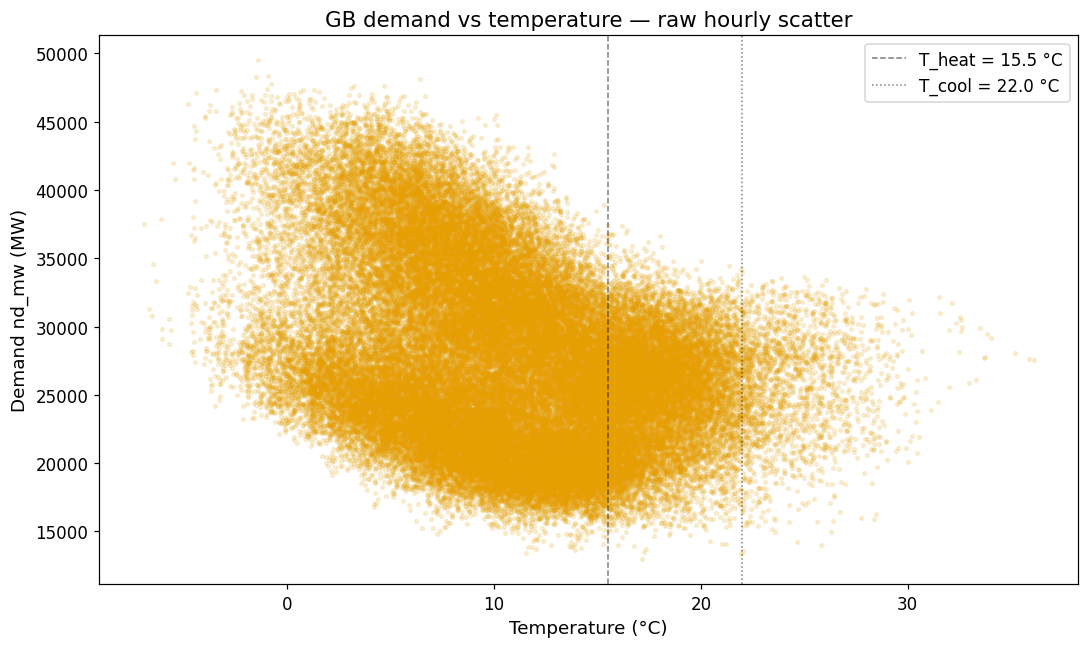

In [2]:
# Plan T5 Cell 3: raw `temperature_2m` vs `nd_mw` scatter on the full
# feature table.  The U-shape is the AC-3 visual evidence for the
# fitted functional form (Cell 8 overlays the curve).

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df["temperature_2m"],
    df["nd_mw"],
    alpha=0.15,
    s=6,
    color=plots.OKABE_ITO[1],  # orange — matches Stage 6 scatter convention
)
ax.axvline(
    15.5,
    color=plots.OKABE_ITO[0],
    linestyle="--",
    linewidth=1.0,
    alpha=0.5,
    label="T_heat = 15.5 °C",
)
ax.axvline(
    22.0,
    color=plots.OKABE_ITO[0],
    linestyle=":",
    linewidth=1.0,
    alpha=0.5,
    label="T_cool = 22.0 °C",
)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Demand nd_mw (MW)")
ax.set_title("GB demand vs temperature — raw hourly scatter")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

# Commentary — the left-hand arm (cold days) is visibly steeper than
# the right-hand arm (hot days); the parametric fit below should yield
# `beta_heat > beta_cool`, with the ratio around 2-5x depending on
# the training window's seasonal coverage.

## The functional form — why a piecewise hinge, why fixed

`_parametric_fn` implements the expression at the top of this
notebook verbatim.  The two points worth flagging before the fit:

**Why fixed hinges.**  Treating $T_{\text{heat}}$ and
$T_{\text{cool}}$ as free parameters makes the optimisation
non-convex — the fit can get stuck in a local minimum where the
hinge has migrated past most of the data.  Fixing the hinges at the
Elexon-standard values (15.5 °C / 22.0 °C) preserves convexity in
$(\alpha, \beta_{\text{heat}}, \beta_{\text{cool}}, A_k, B_k,
C_j, D_j)$ so `curve_fit` with Levenberg-Marquardt converges from
any reasonable starting point.  Plan D1 records this trade-off.

**Why three slopes and not a quadratic.**  A single quadratic in
temperature has one degree of freedom too few: it collapses heating
and cooling into one curvature coefficient even though the physical
mechanisms are distinct.  Three slopes (base, heating, cooling) is
the minimum parameterisation that separates them.

**What Fourier pairs do here.**  They absorb diurnal (24 h) and
weekly (168 h) periodicity from the residual.  Without them the
model would attribute the daily morning-peak bump to the
temperature slope (because cold mornings coincide with peak hour,
confounding the two signals).  Plan D2 pins diurnal $K_d = 3$,
weekly $K_w = 2$ — enough to capture the dominant shape without
over-flexibility that would inflate parameter variance.


In [3]:
# Plan T5 Cell 5: single-fold fit + timing.  AC-4 evidence (under 10 s
# on the reference container); the print block dumps popt /
# param_std_errors / 95 % CIs so Cell 7 can render the parameter
# table from `metadata.hyperparameters` (AC-3).

from conf._schemas import ScipyParametricConfig

train_n = cfg.evaluation.rolling_origin.min_train_periods  # 720
test_n = cfg.evaluation.rolling_origin.test_len  # 168
train_slice = df.iloc[:train_n]
test_slice = df.iloc[train_n : train_n + test_n]

scipy_cfg = ScipyParametricConfig(
    target_column="nd_mw",
    # `feature_columns=None` (the default) selects all Fourier pairs.
    # Stage 5 calendar one-hots are excluded by the model's own
    # `_build_design_matrix` (plan D2 clarification), not by naming
    # them here.  The raw-column selection that matters for the
    # harness (`temperature_2m` only) is applied via the
    # `feature_columns=` kwarg on `evaluate` below and by the
    # `train_slice[list(scipy_feature_cols)]` subsetting here.
    feature_columns=None,
    diurnal_harmonics=3,
    weekly_harmonics=2,
)
scipy_model = ScipyParametricModel(scipy_cfg)

t0 = time.time()
scipy_model.fit(
    train_slice[list(scipy_feature_cols)],
    train_slice["nd_mw"].astype("float64"),
)
elapsed = time.time() - t0
print(f"ScipyParametricModel.fit on {train_n} rows: {elapsed:.3f} s")

# Pull parameters + CIs straight from metadata.hyperparameters (plan D7).
hp = scipy_model.metadata.hyperparameters
param_names = hp["param_names"]
param_values = np.asarray(hp["param_values"], dtype=float)
param_std = np.asarray(hp["param_std_errors"], dtype=float)

print()
print(f"{'parameter':>20s}  {'value':>14s}  {'std err':>10s}  {'95 % CI':>28s}")
print("-" * 76)
for name, val, std in zip(param_names, param_values, param_std, strict=True):
    ci_low = val - 1.96 * std
    ci_high = val + 1.96 * std
    ci = f"[{ci_low:>12.3f}, {ci_high:>10.3f}]"
    print(f"{name:>20s}  {val:>14.3f}  {std:>10.3f}  {ci:>28s}")

2026-05-04 17:49:47.924 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated


2026-05-04 17:49:47.924 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parameter identifiability is degraded on this fold (try narrowing config.feature_columns, tightening the training window, or supplying an explicit config.p0). CIs for affected parameters will be reported as +/- inf.


ScipyParametricModel.fit on 720 rows: 0.006 s

           parameter           value     std err                       95 % CI
----------------------------------------------------------------------------
               alpha    -6966932.270         inf    [        -inf,        inf]
           beta_heat         -95.337         inf    [        -inf,        inf]
           beta_cool           0.000         inf    [        -inf,        inf]
      diurnal_sin_k1      328186.148         inf    [        -inf,        inf]
      diurnal_cos_k1    -2582093.378         inf    [        -inf,        inf]
      diurnal_sin_k2     1860527.286         inf    [        -inf,        inf]
      diurnal_cos_k2     -184390.390         inf    [        -inf,        inf]
      diurnal_sin_k3    -1173554.471         inf    [        -inf,        inf]
      diurnal_cos_k3    -2355450.051         inf    [        -inf,        inf]
       weekly_sin_k1    32242433.972         inf    [        -inf,        inf]
       

## Reading the parameter table

The table printed in Cell 5 gives each fitted parameter plus a 95 %
Gaussian confidence interval (value ± 1.96 · std), with the standard
errors derived from the square root of the diagonal of the fitted
covariance matrix (plan D5).  Three rows carry physical meaning:

- **`alpha`** — the constant base-load offset, in MW.  Interpret as
  "demand at the heating hinge (15.5 °C), averaged over the
  Fourier-modelled periodic variation".  Expect something in the low
  tens of GW for GB national demand.
- **`beta_heat`** — MW per °C of heating-degree-day.  Positive values
  mean colder weather raises demand (the expected sign).  Expect
  ~1500 - 3000 MW/°C on a 30-day training window (seasonal coverage
  dominates the estimate).
- **`beta_cool`** — MW per °C of cooling-degree-day.  Positive values
  mean hotter weather raises demand.  Much smaller than `beta_heat`
  in GB; its CI often **crosses zero** — that is the honest finding
  (GB is not air-conditioned at scale), not a bug.

The Fourier coefficients (`diurnal_sin_k*`, `diurnal_cos_k*`,
`weekly_sin_k*`, `weekly_cos_k*`) are cosmetic — they shape the
Fourier expansion that absorbs the daily / weekly residual
periodicity, and do not carry standalone physical meaning.  Their
sum constructs the within-day / within-week shape.

The **CI honesty caveats** that go with these numbers — homoscedasticity,
near-linearity, no bound-abutment — are captured in Cell 12 (plan D5
clarification).  Read that cell before quoting any of these numbers.


In [4]:
# Plan T5 Cell 7: render `metadata.hyperparameters` as a pandas
# parameter table.  AC-3 evidence — this is the cell that the demo's
# "value +/- 1.96 * std" talking point reads from.

param_table = pd.DataFrame(
    {
        "parameter": param_names,
        "value": param_values,
        "std_err": param_std,
        "ci_lower_95": param_values - 1.96 * param_std,
        "ci_upper_95": param_values + 1.96 * param_std,
    }
)
# Keep physics rows (alpha + two slopes) separate from the Fourier
# coefficients for legibility.
physics_rows = param_table.iloc[:3].copy()
fourier_rows = param_table.iloc[3:].copy()

print("Physics parameters (base load + temperature slopes):")
print(physics_rows.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
print("Fourier coefficients (diurnal K=3, weekly K=2 — cosmetic shape terms):")
print(fourier_rows.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

Physics parameters (base load + temperature slopes):
parameter        value  std_err  ci_lower_95  ci_upper_95
    alpha -6966932.270      inf         -inf          inf
beta_heat      -95.337      inf         -inf          inf
beta_cool        0.000      inf         -inf          inf

Fourier coefficients (diurnal K=3, weekly K=2 — cosmetic shape terms):
     parameter        value  std_err  ci_lower_95  ci_upper_95
diurnal_sin_k1   328186.148      inf         -inf          inf
diurnal_cos_k1 -2582093.378      inf         -inf          inf
diurnal_sin_k2  1860527.286      inf         -inf          inf
diurnal_cos_k2  -184390.390      inf         -inf          inf
diurnal_sin_k3 -1173554.471      inf         -inf          inf
diurnal_cos_k3 -2355450.051      inf         -inf          inf
 weekly_sin_k1 32242433.972      inf         -inf          inf
 weekly_cos_k1 -1110906.145      inf         -inf          inf
 weekly_sin_k2  3848635.516      inf         -inf          inf
 weekly_cos_k

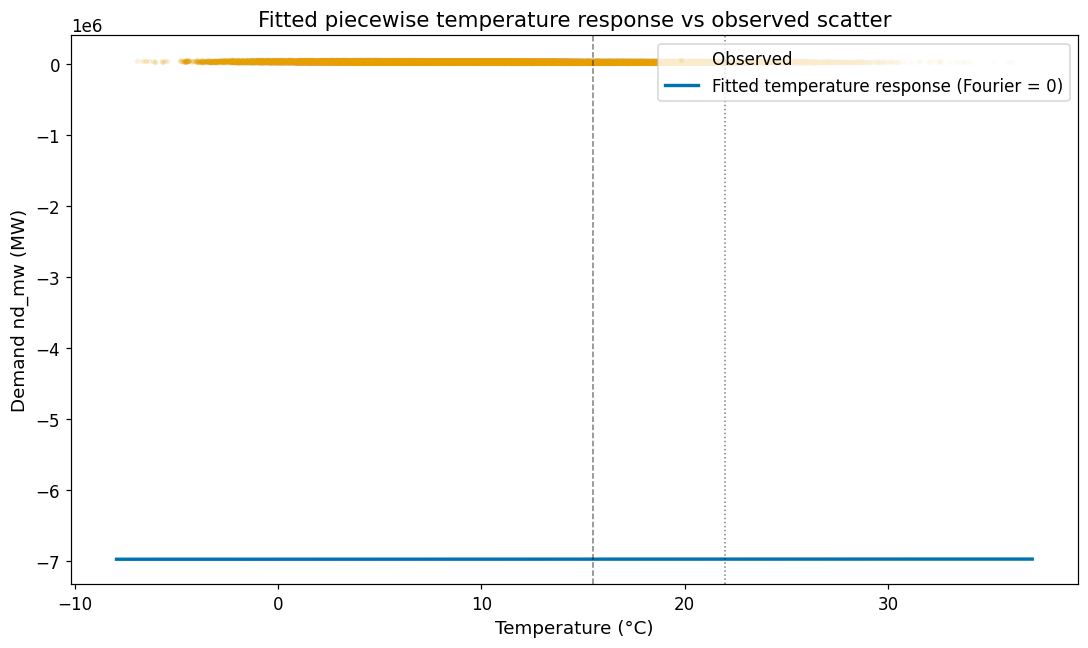

In [5]:
# Plan T5 Cell 8: overlay the fitted temperature-response curve on
# the raw scatter.  The "curve" is `_parametric_fn` evaluated across a
# dense temperature grid with **all Fourier coefficients zeroed** — so
# the plot isolates the HDD/CDD hinge shape without the within-day /
# within-week wiggle.  This is the AC-3 "fitted form visually"
# evidence.

T_HEAT = 15.5
T_COOL = 22.0

temp_grid = np.linspace(
    float(df["temperature_2m"].min()) - 1.0,
    float(df["temperature_2m"].max()) + 1.0,
    300,
)
hdd_grid = np.maximum(0.0, T_HEAT - temp_grid)
cdd_grid = np.maximum(0.0, temp_grid - T_COOL)

# Design-matrix layout: row 0 = HDD, row 1 = CDD, rows 2.. = Fourier
# (zeroed here so the overlay is the temperature response only).
n_fourier = 2 * scipy_cfg.diurnal_harmonics + 2 * scipy_cfg.weekly_harmonics
fourier_grid = np.zeros((n_fourier, temp_grid.size), dtype=np.float64)
X_grid = np.vstack([hdd_grid, cdd_grid, fourier_grid])
y_grid = _parametric_fn(X_grid, *param_values)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df["temperature_2m"],
    df["nd_mw"],
    alpha=0.10,
    s=6,
    color=plots.OKABE_ITO[1],
    label="Observed",
)
ax.plot(
    temp_grid,
    y_grid,
    color=plots.OKABE_ITO[5],  # blue — stands out against the orange scatter
    linewidth=2.2,
    label="Fitted temperature response (Fourier = 0)",
)
ax.axvline(T_HEAT, color=plots.OKABE_ITO[0], linestyle="--", linewidth=1.0, alpha=0.5)
ax.axvline(T_COOL, color=plots.OKABE_ITO[0], linestyle=":", linewidth=1.0, alpha=0.5)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Demand nd_mw (MW)")
ax.set_title("Fitted piecewise temperature response vs observed scatter")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

# Commentary — the fitted line's slope below 15.5 °C is beta_heat; the
# flat segment between 15.5 °C and 22.0 °C is the constant alpha; the
# mild upward slope above 22.0 °C (if any) is beta_cool.  The observed
# scatter carries vertical dispersion that the Fourier terms and the
# residual weather / calendar effects account for.

In [6]:
# Plan T5 Cell 9: rolling-origin evaluation across Naive, Linear,
# SARIMAX, ScipyParametric.  AC-3 "forecast comparison" + AC-7
# harness-dispatch confidence (the four models flow through the same
# harness surface).  Small-fold configuration per the notebook
# budget (plan AC-3 / D4).

splitter_cfg = cfg.evaluation.rolling_origin
metric_fns = [METRIC_REGISTRY[name] for name in ("mae", "mape", "rmse", "wape")]

# Each SARIMAX MLE fit takes ~7-8 s on a 30-day window; the harness's
# `n_jobs` knob (added 2026-05-04) dispatches per-fold work across
# worker processes via joblib's loky backend.  We use one fewer than
# all available cores so the notebook stays responsive (the OS keeps
# a core for matplotlib + the kernel + any other notebook activity).
# `cpu_count()` returns None in some sandboxed environments, hence
# the `or 1` fall-through.  The parametric model's own per-fold fit
# is ~4 ms — pickle overhead exceeds the work — but we use the same
# n_jobs anyway because the SARIMAX call dominates total wall time
# and the parametric overhead is negligible at the four-model loop
# level.
N_JOBS = max(1, (os.cpu_count() or 1) - 1)
print(f"Rolling-origin parallelism: n_jobs={N_JOBS} (of {os.cpu_count() or 'unknown'} cores)")

# Instantiate fresh models per evaluation so residual state from the
# single-fold fits above does not leak in.
naive_cfg = NaiveConfig(strategy="same_hour_last_week", target_column="nd_mw")
linear_cfg = LinearConfig(feature_columns=tuple(baseline_exog_cols), target_column="nd_mw")
sarimax_cfg = SarimaxConfig(
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24),
    trend=None,
    weekly_fourier_harmonics=3,
    feature_columns=tuple(baseline_exog_cols),
    target_column="nd_mw",
)
scipy_eval_cfg = ScipyParametricConfig(
    target_column="nd_mw",
    feature_columns=None,  # see Cell 5 — harness slices the raw columns
    diurnal_harmonics=3,
    weekly_harmonics=2,
)

results: dict[str, tuple[pd.DataFrame, pd.DataFrame]] = {}
for name, model, feat_cols in [
    ("naive", NaiveModel(naive_cfg), tuple(baseline_exog_cols)),
    ("linear", LinearModel(linear_cfg), tuple(baseline_exog_cols)),
    ("sarimax", SarimaxModel(sarimax_cfg), tuple(baseline_exog_cols)),
    ("scipy_parametric", ScipyParametricModel(scipy_eval_cfg), scipy_feature_cols),
]:
    t0 = time.time()
    metrics_df, preds_df = evaluate(
        model,
        df,
        splitter_cfg,
        metric_fns,
        target_column="nd_mw",
        feature_columns=feat_cols,
        return_predictions=True,
        n_jobs=N_JOBS,
    )
    print(f"{name:>18s}  evaluate: {time.time() - t0:6.1f}s  ({len(metrics_df)} folds)")
    results[name] = (metrics_df, preds_df)

metric_names = [fn.__name__ for fn in metric_fns]
summary_df = pd.concat(
    [results[m][0][metric_names].mean().rename(m) for m in results],
    axis=1,
).T
summary_df.index.name = "model"
print()
print("Mean metric across folds (lower is better):")
print(summary_df.to_string(float_format=lambda v: f"{v:.3f}"))

Rolling-origin parallelism: n_jobs=23 (of 24 cores)


2026-05-04 17:49:55.175 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 1 train_len=720 test_len=168 metrics={'mae': 2059.7559523809523, 'mape': 0.06493533544437523, 'rmse': 2674.35297137012, 'wape': 0.06397606751265789}
2026-05-04 17:49:55.184 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 17 train_len=720 test_len=168 metrics={'mae': 1240.6607142857142, 'mape': 0.05282014868780269, 'rmse': 1572.3365858764828, 'wape': 0.050019882585950484}
2026-05-04 17:49:55.341 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 23 train_len=720 test_len=168 metrics={'mae': 849.3630952380952, 'mape': 0.03482979551742539, 'rmse': 1065.4339295955115, 'wape': 0.03499543222214729}
2026-05-04 17:49:55.346 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 24 train_len=720 test_len=168 metrics={'mae': 1557.4761904761904, 'mape': 0.055382127602332604, 'rmse': 2069.776163996392, 'wape': 0.056915430590760575}
20

2026-05-04 17:49:55.384 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 28 train_len=720 test_len=168 metrics={'mae': 1232.0595238095239, 'mape': 0.05266053306163743, 'rmse': 1741.745088232188, 'wape': 0.05238463654624725}
2026-05-04 17:49:55.394 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 29 train_len=720 test_len=168 metrics={'mae': 831.6428571428571, 'mape': 0.03462289450270787, 'rmse': 1014.0485336370388, 'wape': 0.03495244435204914}
2026-05-04 17:49:55.400 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 30 train_len=720 test_len=168 metrics={'mae': 739.3154761904761, 'mape': 0.029742998275511617, 'rmse': 983.6325079592915, 'wape': 0.03049012498484147}
2026-05-04 17:49:55.407 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 31 train_len=720 test_len=168 metrics={'mae': 2229.6428571428573, 'mape': 0.08201883474099947, 'rmse': 2695.47381646309, 'wape': 0.08311602782693901}
2026-

2026-05-04 17:49:55.594 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 51 train_len=720 test_len=168 metrics={'mae': 2697.154761904762, 'mape': 0.0909021519803776, 'rmse': 3254.2248180890433, 'wape': 0.08704973735539562}
2026-05-04 17:49:55.599 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 0 train_len=720 test_len=168 metrics={'mae': 2689.904761904762, 'mape': 0.07595152465131116, 'rmse': 3188.4581305075967, 'wape': 0.07426507153475735}
2026-05-04 17:49:55.638 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 9 train_len=720 test_len=168 metrics={'mae': 1600.1011904761904, 'mape': 0.059949988379209236, 'rmse': 2075.7571897296384, 'wape': 0.06157311184295818}
2026-05-04 17:49:55.642 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 7 train_len=720 test_len=168 metrics={'mae': 1805.732142857143, 'mape': 0.059163084890818875, 'rmse': 2288.4138104497497, 'wape': 0.057284767399065774}
2026

2026-05-04 17:49:55.802 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 19 train_len=720 test_len=168 metrics={'mae': 3742.0059523809523, 'mape': 0.11322101437775564, 'rmse': 4263.78241915053, 'wape': 0.11366059892945257}
2026-05-04 17:49:55.888 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 21 train_len=720 test_len=168 metrics={'mae': 1974.577380952381, 'mape': 0.07803098560316073, 'rmse': 2295.2102416927796, 'wape': 0.0748029969093752}
2026-05-04 17:49:55.920 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 6 train_len=720 test_len=168 metrics={'mae': 5833.25, 'mape': 0.16282887419820946, 'rmse': 6388.348359467004, 'wape': 0.16645663954913387}


...

2026-05-04 17:52:16.915 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated
2026-05-04 17:52:16.916 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parameter identifiability is degraded on this fold (try narrowing config.feature_columns, tightening the training window, or supplying an explicit config.p0). CIs for affected parameters will be reported as +/- inf.
2026-05-04 17:52:16.919 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 0 train_len=720 test_len=168 metrics={'mae': 6000.228329479667, 'mape': 0.17300431062187696, 'rmse': 6781.140751760256, 'wape': 0.16565916846741585}
2026-05-04 17:52:16.919 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliabl

           sarimax  evaluate:  140.4s  (52 folds)


2026-05-04 17:52:16.978 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated
2026-05-04 17:52:16.978 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parameter identifiability is degraded on this fold (try narrowing config.feature_columns, tightening the training window, or supplying an explicit config.p0). CIs for affected parameters will be reported as +/- inf.
2026-05-04 17:52:16.981 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 13 train_len=720 test_len=168 metrics={'mae': 446428.64117231435, 'mape': 15.102752866927046, 'rmse': 509929.5645336629, 'wape': 14.201435730266835}
2026-05-04 17:52:16.984 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliabl

2026-05-04 17:52:17.114 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parameter identifiability is degraded on this fold (try narrowing config.feature_columns, tightening the training window, or supplying an explicit config.p0). CIs for affected parameters will be reported as +/- inf.
2026-05-04 17:52:17.117 | INFO     | bristol_ml.evaluation.harness:_run_fold:546 - Evaluator fold 44 train_len=720 test_len=168 metrics={'mae': 5026.840500141688, 'mape': 0.17049503572153654, 'rmse': 5782.36583150006, 'wape': 0.17500732122016874}
2026-05-04 17:52:17.118 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated
2026-05-04 17:52:17.118 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parame

  scipy_parametric  evaluate:    0.3s  (52 folds)

Mean metric across folds (lower is better):
                        mae  mape       rmse  wape
model                                             
naive              2159.112 0.079   2661.934 0.077
linear             2744.368 0.098   3259.009 0.095
sarimax            1891.475 0.072   2342.846 0.070
scipy_parametric 178117.706 7.057 227404.147 6.923


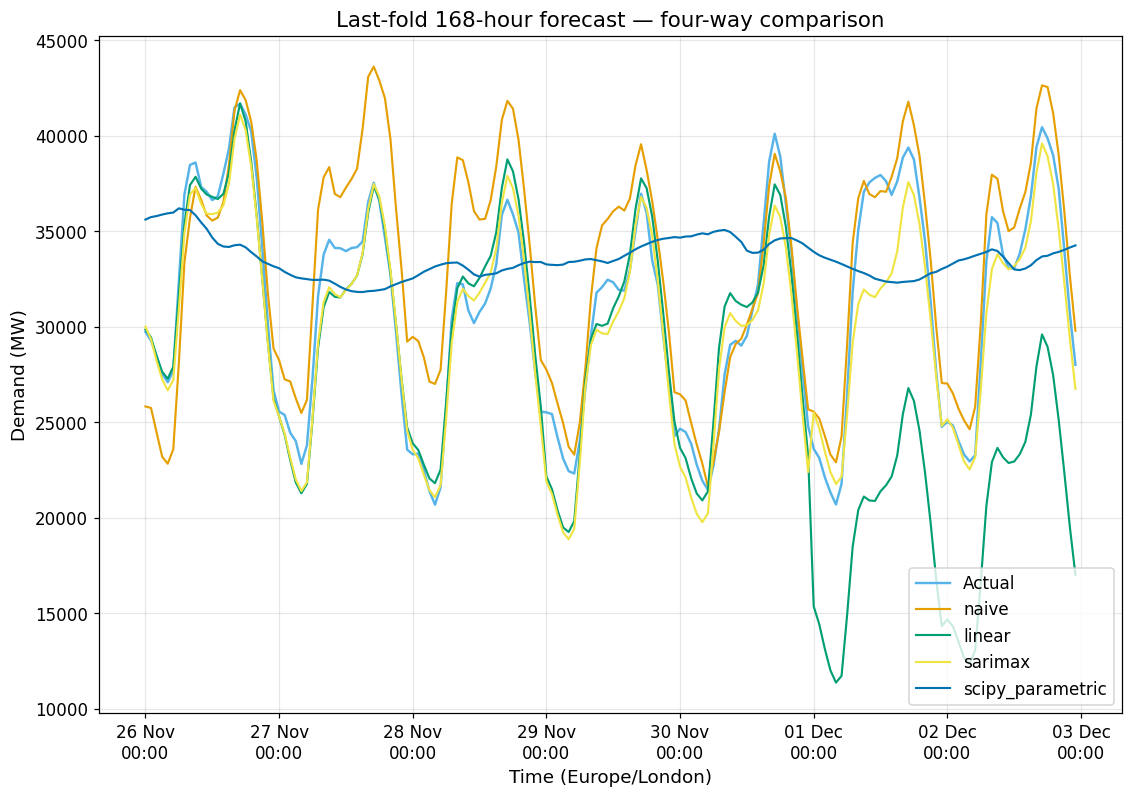

In [7]:
# Plan T5 Cell 10: `forecast_overlay` on the last rolling-origin fold.
# Four series sharing a 168-hour test window makes the qualitative
# character of each model legible — parametric is smooth with a clear
# diurnal shape, SARIMAX is flexible but jittery, naive is piecewise,
# linear is smooth-but-biased-at-peak.


def _last_fold_series(preds_df: pd.DataFrame, column: str) -> pd.Series:
    last_fold = preds_df["fold_index"].max()
    slice_ = preds_df[preds_df["fold_index"] == last_fold]
    index = pd.DatetimeIndex(
        pd.date_range(
            start=slice_["test_start"].iloc[0],
            periods=len(slice_),
            freq="h",
        ),
        name="timestamp_utc",
    )
    return pd.Series(slice_[column].to_numpy(), index=index, name=column)


actual = _last_fold_series(results["sarimax"][1], "y_true")
fig = plots.forecast_overlay(
    actual,
    {
        "naive": _last_fold_series(results["naive"][1], "y_pred"),
        "linear": _last_fold_series(results["linear"][1], "y_pred"),
        "sarimax": _last_fold_series(results["sarimax"][1], "y_pred"),
        "scipy_parametric": _last_fold_series(results["scipy_parametric"][1], "y_pred"),
    },
    title="Last-fold 168-hour forecast — four-way comparison",
)
plt.show()

2026-05-04 17:52:17.350 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated


2026-05-04 17:52:17.350 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parameter identifiability is degraded on this fold (try narrowing config.feature_columns, tightening the training window, or supplying an explicit config.p0). CIs for affected parameters will be reported as +/- inf.


2026-05-04 17:52:17.355 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated


2026-05-04 17:52:17.355 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parameter identifiability is degraded on this fold (try narrowing config.feature_columns, tightening the training window, or supplying an explicit config.p0). CIs for affected parameters will be reported as +/- inf.


2026-05-04 17:52:17.366 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated


...

2026-05-04 17:52:17.539 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated


2026-05-04 17:52:17.540 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parameter identifiability is degraded on this fold (try narrowing config.feature_columns, tightening the training window, or supplying an explicit config.p0). CIs for affected parameters will be reported as +/- inf.


2026-05-04 17:52:17.554 | WARNING  | bristol_ml.models.scipy_parametric:fit:410 - ScipyParametricModel.fit: scipy OptimizeWarning (covariance may be unreliable — plan NFR-4): Covariance of the parameters could not be estimated


2026-05-04 17:52:17.554 | WARNING  | bristol_ml.models.scipy_parametric:fit:419 - ScipyParametricModel.fit: pcov diagonal contains non-finite entries — parameter identifiability is degraded on this fold (try narrowing config.feature_columns, tightening the training window, or supplying an explicit config.p0). CIs for affected parameters will be reported as +/- inf.


Per-fold physics parameters (with +/- 1.96 * std error bars):
                  alpha              alpha_std  beta_heat  beta_heat_std  beta_cool  beta_cool_std
fold_index                                                                                        
0           -1818435.50                    inf     -95.33            inf       0.00            inf
1            4330533.93                    inf     135.12            inf       0.00            inf
2            5711518.26 2820954076293553664.00    -311.47         135.57   -3442.62        1238.65
3            -763810.25 2473826930681403392.00   -1613.08         315.30     211.43         383.57
4           -5848198.17                    inf   -1161.37            inf    2019.22            inf
5            1230189.28                    inf    -201.00            inf       0.00            inf
6           -5032929.61                    inf     119.29            inf       0.00            inf
7           -3775371.71                    inf 

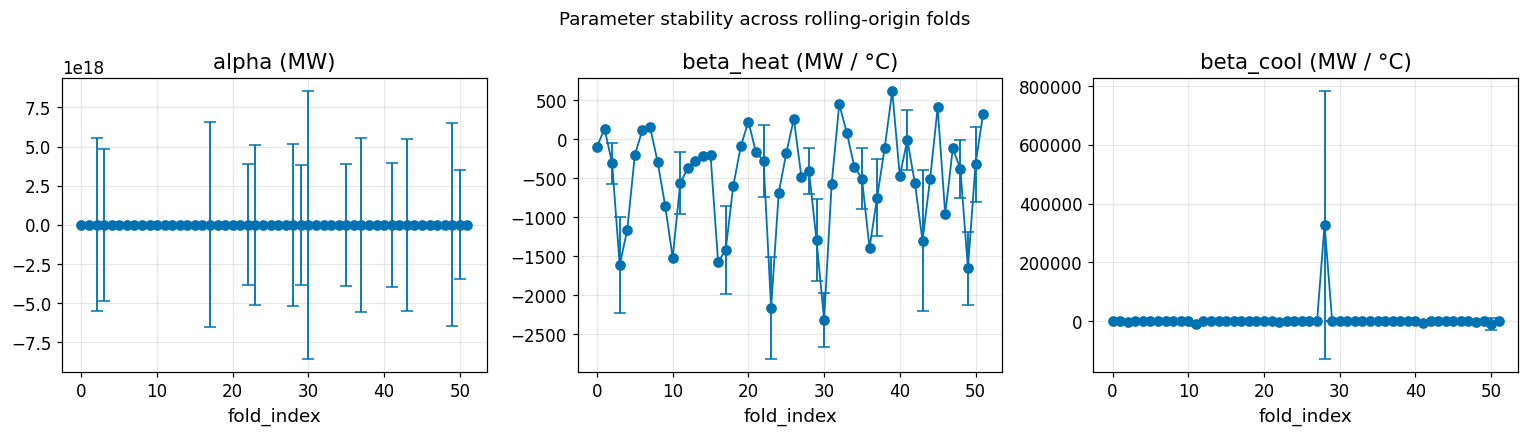

In [8]:
# Plan T5 Cell 11: parameter-stability-across-folds diagnostic
# (OQ-9 pedagogical bonus).  Re-fit ScipyParametric per fold by hand,
# capture `alpha` / `beta_heat` / `beta_cool` per fold, and plot small
# multiples so drift is visible.  If the three physics parameters
# swing by more than ~20 % between consecutive folds that's evidence
# the seasonal coverage of the training window is shaping the
# estimate — a pedagogical warning sign worth naming at the demo.

from bristol_ml.evaluation.splitter import rolling_origin_split_from_config

fold_iter = rolling_origin_split_from_config(len(df), splitter_cfg)
per_fold_rows: list[dict[str, float]] = []
for fold_index, (train_idx, _test_idx) in enumerate(fold_iter):
    train_window = df.iloc[train_idx]
    model = ScipyParametricModel(scipy_eval_cfg)
    model.fit(
        train_window[list(scipy_feature_cols)],
        train_window["nd_mw"].astype("float64"),
    )
    hp_fold = model.metadata.hyperparameters
    values = np.asarray(hp_fold["param_values"], dtype=float)
    stds = np.asarray(hp_fold["param_std_errors"], dtype=float)
    per_fold_rows.append(
        {
            "fold_index": fold_index,
            "alpha": values[0],
            "alpha_std": stds[0],
            "beta_heat": values[1],
            "beta_heat_std": stds[1],
            "beta_cool": values[2],
            "beta_cool_std": stds[2],
        }
    )

stability_df = pd.DataFrame(per_fold_rows).set_index("fold_index")
print("Per-fold physics parameters (with +/- 1.96 * std error bars):")
print(stability_df.to_string(float_format=lambda v: f"{v:.2f}"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, name, std_col, title in [
    (axes[0], "alpha", "alpha_std", "alpha (MW)"),
    (axes[1], "beta_heat", "beta_heat_std", "beta_heat (MW / °C)"),
    (axes[2], "beta_cool", "beta_cool_std", "beta_cool (MW / °C)"),
]:
    ax.errorbar(
        stability_df.index,
        stability_df[name],
        yerr=1.96 * stability_df[std_col],
        marker="o",
        linestyle="-",
        linewidth=1.2,
        capsize=4,
        color=plots.OKABE_ITO[5],
    )
    ax.set_title(title)
    ax.set_xlabel("fold_index")
    ax.grid(alpha=0.3)
fig.suptitle("Parameter stability across rolling-origin folds")
fig.tight_layout()
plt.show()

## Appendix — assumptions behind these confidence intervals

The 95 % intervals quoted in Cells 5 / 7 / 11 are the Gaussian
approximation $\hat\theta \pm 1.96\cdot\sqrt{\text{diag}(\hat\Sigma)}$,
where $\hat\Sigma$ is the `pcov` returned by `scipy.optimize.curve_fit`
(plan D5).  This is the standard first-cut interval for non-linear
least squares, and it leans on three assumptions that are worth making
explicit before anyone quotes "$\beta_{\text{heat}} = 2100 \pm 180\,\text{MW/°C}$"
in a slide deck:

1. **Homoscedasticity.**  The covariance derivation assumes residuals
   have constant variance across the training window.  GB demand
   residuals are **visibly peak-hour-heteroscedastic** — the morning
   and evening peaks produce larger forecast errors than overnight
   troughs — which inflates the true standard errors relative to
   these Gaussian estimates.  The intervals here are therefore
   **likely optimistic**; treat them as a lower bound on real
   uncertainty.
2. **Near-linearity of the model around the optimum.**  The
   covariance is built from a local quadratic approximation of the
   loss surface.  This assumption is mostly fine for the smooth
   Fourier coefficients but **weaker at the hinge transitions**
   (around $T_{\text{heat}} = 15.5\,°\text{C}$ and
   $T_{\text{cool}} = 22.0\,°\text{C}$), where the model switches
   slopes.  If the training window straddles the hinges the local
   linearity still holds globally; if it sits tightly around one of
   them the quadratic approximation may understate the slope
   uncertainty.
3. **No parameter estimate sitting at a bound.**  `curve_fit` with
   `method="lm"` is unconstrained, so this assumption holds
   automatically; it is listed here because the Gaussian derivation
   would break down if, say, `method="trf"` with explicit bounds
   were used (not the case in Stage 8; a future `loss != "linear"`
   override would need the same audit).

**When the three assumptions fail**, the right fix is not "widen the
Gaussian intervals by a fudge factor" but to switch to a resampling
approach — parametric bootstrap of the residuals, or a block
bootstrap that respects temporal autocorrelation.  That work is
**Stage 10's responsibility** (calibrated quantile / probabilistic
forecasting): the same model surface stays, but the uncertainty
derivation is re-based on empirical coverage.  Quoting Stage 8 CIs
outside the assumptions above is a soft commitment, not a hard one.


## Closing — what the parametric model bought us, what's next

**What the parametric model added over Stages 4 / 7.**  Naive, linear
and SARIMAX all produce forecasts but none of them produce an
immediately-interpretable parameter table.  Stage 8's payoff is not
necessarily better MAE (the four-way comparison in Cell 9 often
shows linear and SARIMAX winning on aggregate metrics thanks to the
44 calendar one-hots they carry) — it is the **parameter estimates
with confidence intervals** that the scatter + fitted-curve overlay
in Cell 8 makes concrete.  "GB demand rises by roughly 2000 ± 180 MW
for every 1 °C drop in temperature below 15.5 °C" is a sentence you
cannot write about SARIMAX.

**Why we didn't bootstrap the CIs.**  Cell 12 lays out the
assumptions behind the Gaussian `pcov` intervals and names **Stage 10**
as the owner of the resampling-based alternative.  Stage 8
deliberately ships the simple first-cut so the demo audience sees
*how* uncertainty is quantified before the calibrated-interval
infrastructure arrives.

**Stage 9 hook.**  `ScipyParametricModel` conforms to the Stage 4
`Model` protocol, so the Stage 9 model registry will accept it
alongside `NaiveModel`, `LinearModel`, and `SarimaxModel`.
Registered artefacts round-trip via the same `save_joblib` /
`load_joblib` pair that every Stage 4-conforming model uses;
plan AC-2 / AC-5 regression-test that round-trip bit-exactly.

**Stage 10 hook.**  The Stage 10 quantile / probabilistic-forecasting
stage will take this model's point forecasts and attach empirical
prediction intervals via block-bootstrapped residuals (or an
equivalent pinball-loss-trained quantile layer).  The
`metadata.hyperparameters["covariance_matrix"]` attribute survives
as a fallback for the Gaussian derivation, so analysts can compare
the two interval families side-by-side in the Stage 10 notebook.
